# Introdução às Redes Convolucionais com PyTorch

Neste notebook, vamos explorar Redes Neurais usando a biblioteca PyTorch. Vamos começar com uma Rede Neural Totalmente Conectada (Fully Connected Network) para classificar dígitos do dataset MNIST. Em seguida, substituiremos a rede por uma Rede Neural Convolucional (CNN) e compararemos os resultados.

## Objetivos
- Carregar e preprocessar o dataset MNIST.
- Implementar uma Rede Neural Totalmente Conectada.
- Treinar e avaliar a rede.
- Substituir a rede por uma CNN e comparar os resultados.

In [1]:
# Importando as bibliotecas necessárias
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
# from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

## Carregando e Preprocessando o Dataset MNIST

O dataset MNIST contém 60.000 imagens de treinamento e 10.000 imagens de teste de dígitos manuscritos, de 0 a 9.

In [2]:
# Download do dataset MNIST into data dir
! wget https://pjreddie.com/media/files/mnist_train.csv -P data

--2025-07-21 00:55:18--  https://pjreddie.com/media/files/mnist_train.csv
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘data/mnist_train.csv’

mnist_train.csv         [ <=>                ]   8.88K  --.-KB/s    in 0s      

2025-07-21 00:55:19 (62.2 MB/s) - ‘data/mnist_train.csv’ saved [9093]



In [15]:
class MNISTDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file) #header = None
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # A primeira coluna é o rótulo
        label = self.data.iloc[idx, 0]
        # As demais colunas são os pixels da imagem
        image = self.data.iloc[idx, 1:].values.astype('uint8').reshape(28, 28)

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
# Transformação para converter a imagem para tensor
transform = transforms.Compose([
    transforms.ToPILImage(),    # Convertendo o array numpy para imagem PIL
    transforms.ToTensor(),      # Convertendo a imagem PIL para tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalizando a imagem
])

# Criando o dataset
mnist_dataset = MNISTDataset("./data/mnist_train.csv", transform=transform)

In [17]:
# Criando índices aleatórios para os subsets de treino e teste
indices = np.arange(len(mnist_dataset))
np.random.shuffle(indices)

train_indices = indices[:10000]  # Primeiros 10.000 índices para o trainset
test_indices = indices[10000:11000]  # Próximos 1.000 índices para o testset

trainset = Subset(mnist_dataset, train_indices)
testset = Subset(mnist_dataset, test_indices)

In [18]:
# Criando DataLoaders para os subsets
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

## Visualizando Algumas Imagens do Dataset

Vamos visualizar algumas imagens do dataset de treino para entender melhor os dados com os quais estamos trabalhando.

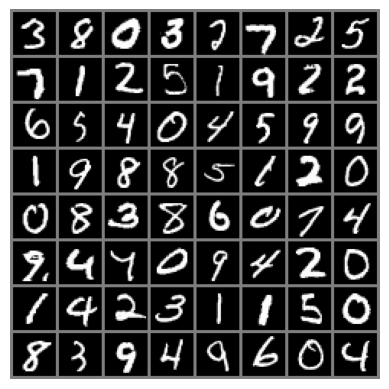

Labels:  3 8 0 3 2 7 2 5


In [19]:
# Função para mostrar uma imagem
def imshow(img):
    img = img / 2 + 0.5  # desnormalizar
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

# Obter algumas imagens de treinamento
images, labels = next(iter(trainloader))

# Mostrar imagens
imshow(torchvision.utils.make_grid(images))
# Mostrar labels
print('Labels: ', ' '.join('%d' % labels[j] for j in range(8)))

In [20]:
def train_model(model, trainloader, criterion, optimizer, num_epochs=5):
    train_losses = []
    accuracies = []
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for i, data in tqdm(enumerate(trainloader, 0), total=len(trainloader)):
            # Obter os inputs; data é uma lista de [inputs, labels]
            inputs, labels = data

            # Zerar os gradientes dos parâmetros otimizados
            optimizer.zero_grad()

            # forward + backward + otimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Estatísticas
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if i % 50 == 49:
                train_losses.append(running_loss / 100)
                running_loss = 0.0

        epoch_acc = 100 * correct / total
        accuracies.append(epoch_acc)
        print(f'Epoch {epoch+1}, Loss: {train_losses[-1]:.3f}, Accuracy: {epoch_acc:.2f}%')
    print('Treinamento concluído')
    return train_losses, accuracies


def test_model(model, testloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Acurácia da rede na base de teste: {100 * correct / total:.2f}%')


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Definindo a Rede Neural Totalmente Conectada

Vamos definir uma arquitetura simples de Rede Neural Totalmente Conectada (FCN).

In [21]:
class FCN(nn.Module):
    def __init__(self):
        super(FCN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

fcn_model = FCN()

In [22]:
fcn_params = count_parameters(fcn_model)
print(f"Total de parâmetros na FCN: {fcn_params}")

Total de parâmetros na FCN: 109386


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(fcn_model.parameters(), lr=0.01, momentum=0.9)

In [24]:
# Treinando a FCN
fcn_losses, fcn_accuracies = train_model(fcn_model, trainloader, criterion, optimizer)

100%|██████████| 157/157 [00:04<00:00, 32.39it/s]


Epoch 1, Loss: 0.252, Accuracy: 67.33%


100%|██████████| 157/157 [00:04<00:00, 34.47it/s]


Epoch 2, Loss: 0.169, Accuracy: 88.65%


100%|██████████| 157/157 [00:05<00:00, 29.87it/s]


Epoch 3, Loss: 0.165, Accuracy: 90.51%


100%|██████████| 157/157 [00:04<00:00, 34.93it/s]


Epoch 4, Loss: 0.128, Accuracy: 92.07%


100%|██████████| 157/157 [00:04<00:00, 32.65it/s]

Epoch 5, Loss: 0.106, Accuracy: 93.28%
Treinamento concluído


In [25]:
# Testando a FCN
test_model(fcn_model, testloader)

Acurácia da rede na base de teste: 92.60%


## Substituindo a Rede Neural por uma CNN

Agora, vamos substituir a Rede Neural Totalmente Conectada por uma Rede Neural Convolucional (CNN) e comparar os resultados.

In [26]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 12, 5)
        self.fc1 = nn.Linear(12 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 12 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

cnn_model = CNN()

In [27]:
cnn_params = count_parameters(cnn_model)
print(f"Total de parâmetros na CNN: {cnn_params}")

Total de parâmetros na CNN: 14970


In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn_model.parameters(), lr=0.01, momentum=0.9)

In [29]:
# Treinando a CNN
cnn_losses, cnn_accuracies = train_model(cnn_model, trainloader, criterion, optimizer)

100%|██████████| 157/157 [00:06<00:00, 24.23it/s]


Epoch 1, Loss: 0.191, Accuracy: 58.25%


100%|██████████| 157/157 [00:06<00:00, 25.73it/s]


Epoch 2, Loss: 0.085, Accuracy: 93.47%


100%|██████████| 157/157 [00:06<00:00, 24.65it/s]


Epoch 3, Loss: 0.068, Accuracy: 95.66%


100%|██████████| 157/157 [00:06<00:00, 25.69it/s]


Epoch 4, Loss: 0.045, Accuracy: 96.88%


100%|██████████| 157/157 [00:06<00:00, 24.51it/s]

Epoch 5, Loss: 0.043, Accuracy: 97.15%
Treinamento concluído


In [30]:
# Testando a CNN
test_model(cnn_model, testloader)

Acurácia da rede na base de teste: 96.30%


## Comparando as duas redes neurais

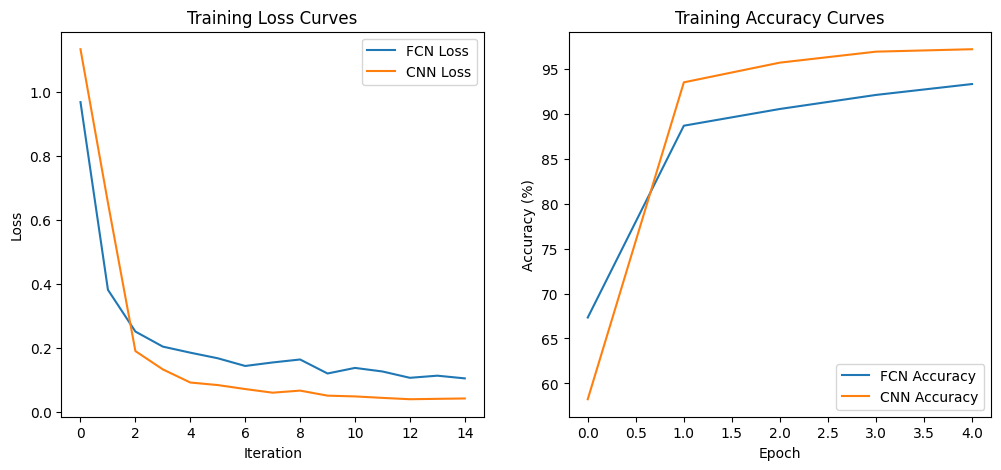

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fcn_losses, label='FCN Loss')
plt.plot(cnn_losses, label='CNN Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fcn_accuracies, label='FCN Accuracy')
plt.plot(cnn_accuracies, label='CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy Curves')
plt.legend()

plt.show()

## Exercícios

### Exercício 1
Altere a estrutura da rede e diminua o número de parâmetros na rede FC. O que se observa no resultado do treinamento?

In [121]:
class FCN_Alt(nn.Module):
    def __init__(self):
        super(FCN_Alt, self).__init__()
        self.fc1 = nn.Linear(28 * 28,64)
        self.fc2 = nn.Linear(64, 10)
        # self.fc3 = nn.Linear(128,64)
        # self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        # x = F.relu(self.fc2(x))
        # x = F.relu(self.fc3(x))
        x = self.fc2(x)
        return x

fcn_model = FCN_Alt()

In [122]:
fcn_params = count_parameters(fcn_model)
print(f"Total de parâmetros na FCN: {fcn_params}")

Total de parâmetros na FCN: 50890


In [123]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(fcn_model.parameters(), lr=0.01, momentum=0.9)

In [124]:
# Treinando a FCN
fcn_losses, fcn_accuracies = train_model(fcn_model, trainloader, criterion, optimizer)

100%|██████████| 157/157 [00:05<00:00, 30.35it/s]


Epoch 1, Loss: 0.228, Accuracy: 77.31%


100%|██████████| 157/157 [00:04<00:00, 34.33it/s]


Epoch 2, Loss: 0.176, Accuracy: 88.97%


100%|██████████| 157/157 [00:04<00:00, 33.95it/s]


Epoch 3, Loss: 0.146, Accuracy: 90.62%


100%|██████████| 157/157 [00:05<00:00, 30.96it/s]


Epoch 4, Loss: 0.125, Accuracy: 91.81%


100%|██████████| 157/157 [00:04<00:00, 34.82it/s]

Epoch 5, Loss: 0.115, Accuracy: 93.06%
Treinamento concluído


In [125]:
# Testando a FCN
test_model(fcn_model, testloader)

Acurácia da rede na base de teste: 90.50%


Observações:
* Diminui uma camada da rede e com isto o número dos parâmetros diminuiu também. O impacto foi visto na acurácia que foi de 92,60% para 90,50%.

### Exercício 2
Aumente o número de filtros convolucionais na CNN. O que se observa no resultado do treinamento em comparação ao anterior? Lembre-se de ajustar os valores das camadas seguintes.

* **Kernel de 6**

In [108]:
class CNN_Alt(nn.Module):
    def __init__(self):
        super(CNN_Alt, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 6)
        self.conv2 = nn.Conv2d(6, 12, 6)
        self.fc1 = nn.Linear(12 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 12 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

cnn_model_alt = CNN_Alt()

In [109]:
cnn_params = count_parameters(cnn_model_alt)
print(f"Total de parâmetros na CNN: {cnn_params}")

Total de parâmetros na CNN: 10452


In [110]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn_model_alt.parameters(), lr=0.01, momentum=0.9)

In [111]:
# Treinando a CNN
cnn_losses, cnn_accuracies = train_model(cnn_model_alt, trainloader, criterion, optimizer)

100%|██████████| 157/157 [00:06<00:00, 22.44it/s]


Epoch 1, Loss: 0.218, Accuracy: 61.50%


100%|██████████| 157/157 [00:05<00:00, 26.77it/s]


Epoch 2, Loss: 0.118, Accuracy: 91.82%


100%|██████████| 157/157 [00:06<00:00, 23.96it/s]


Epoch 3, Loss: 0.077, Accuracy: 94.83%


100%|██████████| 157/157 [00:05<00:00, 26.86it/s]


Epoch 4, Loss: 0.064, Accuracy: 96.40%


100%|██████████| 157/157 [00:06<00:00, 23.98it/s]

Epoch 5, Loss: 0.046, Accuracy: 96.98%
Treinamento concluído


In [112]:
# Testando a CNN
test_model(cnn_model_alt, testloader)

Acurácia da rede na base de teste: 97.30%


* **Kernel de 8**

In [103]:
class CNN_Alt(nn.Module):
    def __init__(self):
        super(CNN_Alt, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 8)
        self.conv2 = nn.Conv2d(6, 12, 8)
        self.fc1 = nn.Linear(12 * 1 * 1, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # CNN
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 12 * 1 * 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

cnn_model_alt = CNN_Alt()

In [102]:
x = torch.rand(1,28,28)
cnn_model_alt(x).shape

torch.Size([12, 1, 1])

In [104]:
cnn_params = count_parameters(cnn_model_alt)
print(f"Total de parâmetros na CNN: {cnn_params}")

Total de parâmetros na CNN: 6492


In [105]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn_model_alt.parameters(), lr=0.01, momentum=0.9)

In [106]:
# Treinando a CNN
cnn_losses, cnn_accuracies = train_model(cnn_model_alt, trainloader, criterion, optimizer)

100%|██████████| 157/157 [00:06<00:00, 23.68it/s]


Epoch 1, Loss: 0.335, Accuracy: 48.46%


100%|██████████| 157/157 [00:05<00:00, 26.54it/s]


Epoch 2, Loss: 0.139, Accuracy: 90.26%


100%|██████████| 157/157 [00:06<00:00, 23.86it/s]


Epoch 3, Loss: 0.093, Accuracy: 93.92%


100%|██████████| 157/157 [00:06<00:00, 26.09it/s]


Epoch 4, Loss: 0.067, Accuracy: 95.59%


100%|██████████| 157/157 [00:07<00:00, 19.75it/s]

Epoch 5, Loss: 0.057, Accuracy: 96.12%
Treinamento concluído


In [107]:
# Testando a CNN
test_model(cnn_model_alt, testloader)

Acurácia da rede na base de teste: 95.80%


Observações:
* Para o kernel de 6 a quantidade de parâmetros diminui aproximadamente 4 mil em comparação com o kernel de 5. A acurácia é mantida em 97.30%
* Para o kernel de 8 a quantidade de parâmetros diminui bastante chegando a 6492. A acurácia é mantida em 95.80%.

A medida que a quantidade de kernel aumenta, os parâmetros de entrada das camadas lineares diminuem.